In [1]:
# !pip install faker
# !pip install python-louvain

In [2]:
import pandas as pd
import numpy as np
from faker import Faker
from datetime import datetime, timedelta

In [3]:
import pandas as pd
import numpy as np
from faker import Faker
from datetime import datetime, timedelta

fake = Faker()
start_date = datetime(2024, 5, 1)
num_days = 15
num_users = 3000
transactions_per_user = 5  # 사기 사용자의 최대 거래 횟수

# ─── 1. 사용자 정보 초기화 ───────────────────────────────────────────────
users = pd.DataFrame({
    'user_id': range(num_users),
    'ip': [fake.ipv4_public() for _ in range(num_users)],
    'device_id': [fake.uuid4() for _ in range(num_users)],
    'phone_number': [fake.phone_number() for _ in range(num_users)],
    'credit_card': [fake.credit_card_number() for _ in range(num_users)],
})

# ─── 2. 사기 그룹 설정 ───────────────────────────────────────────────────
fraud_group_size = 30
# 사기 사용자 집합 (IP 공유, 카드 공유, 디바이스+폰 공유)
ip_fraud_users = set(np.random.choice(num_users, fraud_group_size, replace=False))
card_fraud_users = set(np.random.choice(num_users, fraud_group_size, replace=False))
device_phone_fraud_users = set(np.random.choice(num_users, fraud_group_size, replace=False))

# ─── 3. “공유 리소스” 리스트 생성 ─────────────────────────────────────────
# 사기 사용자들이 사용할 공용 IP, 카드, 디바이스 ID, 폰 번호 목록을 각각 fraud_group_size 개수만큼 생성
shared_ips = [fake.ipv4_public() for _ in range(fraud_group_size)]
shared_cards = [fake.credit_card_number() for _ in range(fraud_group_size)]
shared_devices = [fake.uuid4() for _ in range(fraud_group_size)]
shared_phones = [fake.phone_number() for _ in range(fraud_group_size)]

# ─── 4. 거래 데이터 생성 ─────────────────────────────────────────────────
transactions = []
for user_id in range(num_users):
    # 사기 사용자일 때 최대 transactions_per_user 회 랜덤 거래, 아니면 5회 고정
    if user_id in ip_fraud_users or user_id in card_fraud_users or user_id in device_phone_fraud_users:
        num_transactions = np.random.randint(1, transactions_per_user + 1)
    else:
        num_transactions = 5

    for _ in range(num_transactions):
        # 거래 날짜 무작위 선택
        day = np.random.choice(num_days)
        date = start_date + timedelta(days=day)

        # 사기 그룹에 속한 사용자는 공용 리소스에서 하나를 랜덤으로 선택
        if user_id in ip_fraud_users:
            ip = shared_ips[np.random.randint(len(shared_ips))]
        else:
            ip = users.at[user_id, 'ip']

        if user_id in card_fraud_users:
            card = shared_cards[np.random.randint(len(shared_cards))]
        else:
            card = users.at[user_id, 'credit_card']

        if user_id in device_phone_fraud_users:
            device = shared_devices[np.random.randint(len(shared_devices))]
            phone = shared_phones[np.random.randint(len(shared_phones))]
        else:
            device = users.at[user_id, 'device_id']
            phone = users.at[user_id, 'phone_number']

        is_fraud = (user_id in ip_fraud_users) or (user_id in card_fraud_users) or (user_id in device_phone_fraud_users)
        transactions.append({
            'transaction_id': fake.uuid4(),
            'user_id': user_id,
            'transaction_time': date,
            'ip': ip,
            'device_id': device,
            'phone_number': phone,
            'credit_card_number': card,
            'order_item': np.random.choice(['스마트폰', '노트북', '식품', '문구', '악세서리','가전제품', '의류', '화장품', '아동용품', '여행용품']),
            'amount': np.random.randint(1000, 300000),
            'is_fraud': is_fraud
        })

# DataFrame으로 변환
transactions_df = pd.DataFrame(transactions)

# 확인용 출력 (예시로 앞 5개 행만 출력)
print(transactions_df.head())


                         transaction_id  user_id transaction_time  \
0  006f9645-c451-4b50-8236-9518afadd48d        0       2024-05-05   
1  42bca164-01cf-4c4f-9217-ff6185dffae2        0       2024-05-09   
2  033b4652-18b4-4bf3-912d-2d7d46fc77b0        0       2024-05-08   
3  3b9519eb-7192-44c0-bdff-275280572342        0       2024-05-06   
4  fc501c62-8e24-4187-a4c9-a91b08b87cdf        0       2024-05-07   

              ip                             device_id      phone_number  \
0  205.238.0.148  47b53283-f54c-4144-b0b6-0c0295896c3e  745-758-0187x938   
1  205.238.0.148  47b53283-f54c-4144-b0b6-0c0295896c3e  745-758-0187x938   
2  205.238.0.148  47b53283-f54c-4144-b0b6-0c0295896c3e  745-758-0187x938   
3  205.238.0.148  47b53283-f54c-4144-b0b6-0c0295896c3e  745-758-0187x938   
4  205.238.0.148  47b53283-f54c-4144-b0b6-0c0295896c3e  745-758-0187x938   

  credit_card_number order_item  amount  is_fraud  
0   4485595030333459       악세서리  182202     False  
1   4485595030333459    

In [4]:
transactions_df.shape

(14836, 10)

In [5]:
transactions_df[transactions_df['is_fraud']==1]

,transaction_id,user_id,transaction_time,ip,device_id,phone_number,credit_card_number,order_item,amount,is_fraud
240,5ebbbcfe-eb4f-4335-b2d5-34a0f37f7262,48,2024-05-14,19.46.76.131,4918e508-1093-42fc-bb22-36d4e56520ce,310-435-9122x79396,4416689778151,악세서리,90489,True
241,8e8ffbfd-833a-415f-9647-cfa1de7adccf,48,2024-05-06,19.46.76.131,5ab161f6-69b2-4779-8054-86f351dc7380,+1-986-284-5250,4416689778151,식품,214307,True
762,2719ed16-7c1f-4888-98a7-5c4e07d384ec,153,2024-05-09,178.215.0.109,a093822a-7947-450d-9e6d-7c62d1d28f3e,726.635.9307x890,213120598205572,식품,288149,True
763,79315489-62b0-4122-8101-dcdaed97b969,153,2024-05-02,178.215.0.109,abcad44a-bf98-422e-a329-fb87430bd612,001-375-261-9308,213120598205572,악세서리,183339,True
764,22319940-187b-47b4-af4d-52a0f7f8d423,153,2024-05-03,178.215.0.109,d88b37eb-c15b-43a5-afbb-d3ae9c932f5f,310-435-9122x79396,213120598205572,여행용품,237054,True
...,...,...,...,...,...,...,...,...,...,...
14601,18c58134-f067-41e1-9ca7-4d4bea240cbd,2952,2024-05-07,159.56.77.210,69f3423b-9603-4fb5-8bb0-dec29fdc1fd0,(886)458-2974,2594268081164650,스마트폰,54725,True
14602,a3101583-aeaf-4bfa-9322-14c6e3bfefd0,2952,2024-05-05,206.254.73.114,69f3423b-9603-4fb5-8bb0-dec29fdc1fd0,(886)458-2974,2594268081164650,식품,23233,True
14603,b815b4af-d65a-4a13-a935-38294bf1bafc,2952,2024-05-09,220.86.52.194,69f3423b-9603-4fb5-8bb0-dec29fdc1fd0,(886)458-2974,2594268081164650,가전제품,7195,True
14604,32c391a0-8346-4d48-a63a-8e73e620f245,2952,2024-05-04,219.158.200.50,69f3423b-9603-4fb5-8bb0-dec29fdc1fd0,(886)458-2974,2594268081164650,가전제품,206375,True


In [6]:
import networkx as nx
import pandas as pd
from community import community_louvain

# Convert the dataframe to a suitable format for graph creation
def build_graph(data):
    G = nx.Graph()
    for _, row in data.iterrows():
        G.add_edge(row['user_id'], row['ip'], weight=1)
        G.add_edge(row['user_id'], row['device_id'], weight=1)
        G.add_edge(row['user_id'], row['credit_card_number'], weight=1)
        G.add_edge(row['user_id'], row['phone_number'], weight=1)

        # Set attributes for nodes
        G.nodes[row['user_id']]['node_type'] = 'user_id'
        G.nodes[row['ip']]['node_type'] = 'ip'
        G.nodes[row['device_id']]['node_type'] = 'device_id'
        G.nodes[row['credit_card_number']]['node_type'] = 'credit_card'
        G.nodes[row['phone_number']]['node_type'] = 'phone_number'
    return G

G = build_graph(transactions_df)


In [7]:
partition = community_louvain.best_partition(G)
for node, comm_id in partition.items():
    G.nodes[node]['community'] = comm_id

# Gathering all nodes by community
from itertools import groupby

all_communities = [list(group) for key, group in groupby(sorted(partition, key=partition.get), key=partition.get)]


In [8]:
# from concurrent.futures import ThreadPoolExecutor, as_completed

In [9]:
# def analyze_community(G, nodes):
#     subgraph = G.subgraph(nodes)
#     comm_density = nx.density(subgraph)
#     modularity_score = community_louvain.modularity(partition, G)
#     user_count = sum(1 for node in nodes if G.nodes[node]['node_type'] == 'user_id')
#     phone_count = sum(1 for node in nodes if G.nodes[node]['node_type'] == 'phone_number')
#     card_count = sum(1 for node in nodes if G.nodes[node]['node_type'] == 'credit_card')
#     return [comm_density, modularity_score, len(nodes), user_count, phone_count, card_count]

# def analyze_communities_parallel(G, all_communities):
#     community_info = []
#     with ThreadPoolExecutor() as executor:
#         futures = {executor.submit(analyze_community, G, nodes): comm_id for comm_id, nodes in enumerate(all_communities)}
#         for future in as_completed(futures):
#             comm_id = futures[future]
#             result = future.result()
#             community_info.append([comm_id] + result)
#     return pd.DataFrame(community_info, columns=['Community ID', 'Density', 'Modularity', 'Size', 'User Count', 'Phone Count', 'Card Count'])

# df_community = analyze_communities_parallel(G, all_communities)


In [13]:
def analyze_community(G, nodes, partition):
    subgraph = G.subgraph(nodes)
    comm_density = nx.density(subgraph)
    modularity_score = community_louvain.modularity(partition, G)
    user_count = sum(1 for node in nodes if G.nodes[node].get('node_type') == 'user_id')
    phone_count = sum(1 for node in nodes if G.nodes[node].get('node_type') == 'phone_number')
    card_count = sum(1 for node in nodes if G.nodes[node].get('node_type') == 'credit_card')
    return [comm_density, modularity_score, len(nodes), user_count, phone_count, card_count]

def analyze_communities_serial(G, all_communities, partition):
    community_info = []
    for comm_id, nodes in enumerate(all_communities):
        print(f"{comm_id}/{len(all_communities)} 진행중", end="\r")
        result = analyze_community(G, nodes, partition)
        community_info.append([comm_id] + result)
    return pd.DataFrame(
        community_info,
        columns=['Community ID', 'Density', 'Modularity', 'Size', 'User Count', 'Phone Count', 'Card Count']
    )

# 실행 예시
df_community = analyze_communities_serial(G, all_communities, partition)


In [14]:
df_community

,Community ID,Density,Modularity,Size,User Count,Phone Count,Card Count
0,0,0.4,0.998557,5,1,1,1
1,1,0.4,0.998557,5,1,1,1
2,2,0.4,0.998557,5,1,1,1
3,3,0.4,0.998557,5,1,1,1
4,4,0.4,0.998557,5,1,1,1
...,...,...,...,...,...,...,...
2909,2909,0.4,0.998557,5,1,1,1
2910,2910,0.4,0.998557,5,1,1,1
2911,2911,0.4,0.998557,5,1,1,1
2912,2912,0.4,0.998557,5,1,1,1


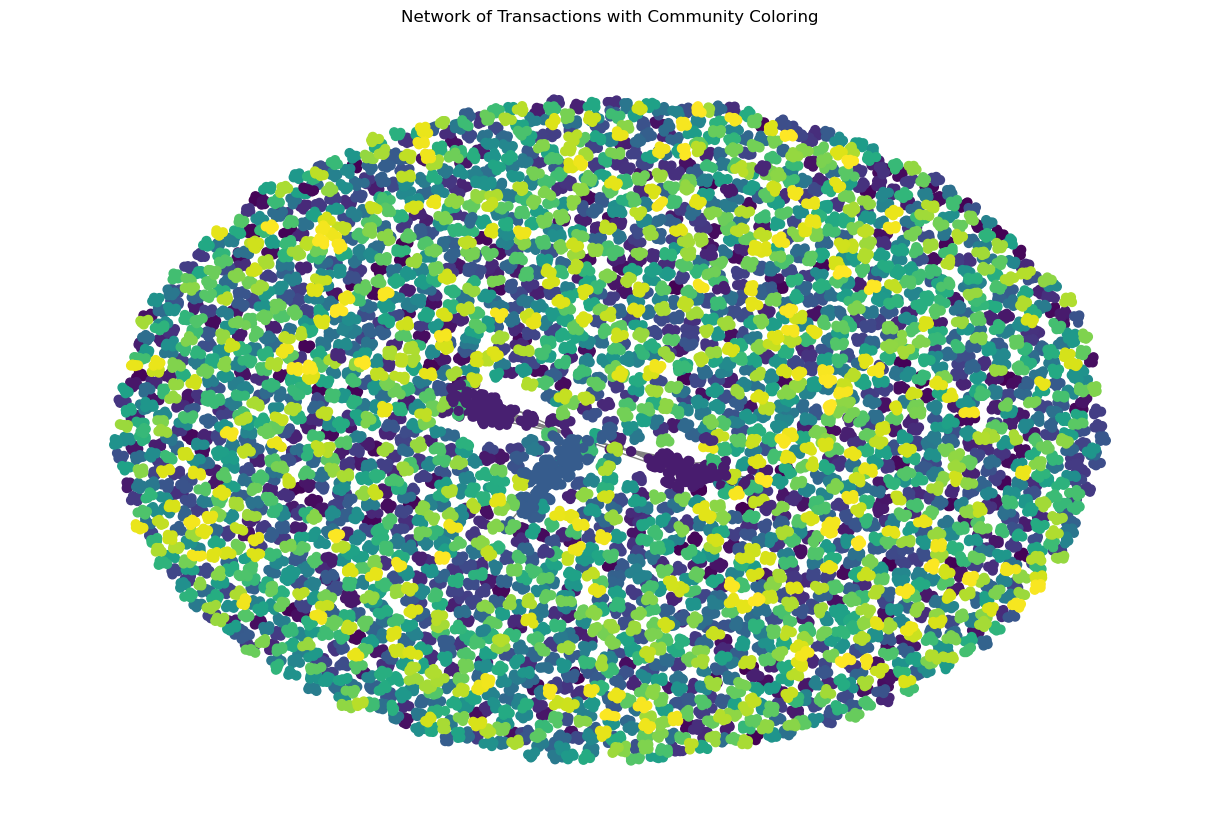

In [15]:
import matplotlib.pyplot as plt

# Color map based on community ID
color_map = [data['community'] for node, data in G.nodes(data=True)]

plt.figure(figsize=(12, 8))
nx.draw(G, node_color=color_map, with_labels=False, node_size=40, edge_color='gray')
plt.title("Network of Transactions with Community Coloring")
plt.show()
